# Classificação Supervisionada com Agglomerative Clustering no Dataset Adult

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Agglomerative Clustering, aplicado ao dataset Adult. Todas as etapas são explicadas e o código é comentado para facilitar o entendimento.

In [8]:
# Importação das bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.cluster.hierarchy import dendrogram, linkage
import os

# Garante que a pasta 'img' existe
os.makedirs('img', exist_ok=True)

## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, visualização e implementação do Agglomerative Clustering.

In [9]:
# Carregamento do dataset Adult
# O arquivo deve estar em 'src/data/adult.csv' ou caminho equivalente

dataset_path = 'data/AdultDataset/adult.data'
df = pd.read_csv(dataset_path, header=None, na_values=' ?', skipinitialspace=True)
df.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
print(f"Formato do dataset: {df.shape}")
df.head()

Formato do dataset: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Carregamento e Pré-processamento dos Dados

Carregamos o dataset Adult, removemos valores ausentes, codificamos variáveis categóricas e normalizamos os dados.

In [10]:
# Pré-processamento dos dados
# 1. Remover valores ausentes
# 2. Codificar variáveis categóricas
# 3. Normalizar os dados

df = df.replace('?', np.nan)
df = df.dropna()

# Separar features e target
target_col = 'income'  # ajuste se necessário
X = df.drop(target_col, axis=1)
y = df[target_col]

# Codificação de variáveis categóricas
def encode_features(X):
    X_encoded = X.copy()
    for col in X_encoded.select_dtypes(include=['object']).columns:
        X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])
    return X_encoded

X_encoded = encode_features(X)

# Normalização
def normalize_features(X):
    scaler = StandardScaler()
    return scaler.fit_transform(X)

X_norm = normalize_features(X_encoded)

# Exibir shape final
display(pd.DataFrame(X_norm).head())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.042796,2.936000,-1.062722,-0.349865,1.128918,0.947847,-1.479055,-0.261249,0.385048,0.692806,0.146092,-0.218586,-0.077734,0.264924
1,0.880288,1.887682,-1.007871,-0.349865,1.128918,-0.387275,-0.734545,-0.885737,0.385048,0.692806,-0.147445,-0.218586,-2.331531,0.264924
2,-0.033340,-0.208955,0.244693,0.174763,-0.439738,-1.722396,-0.238206,-0.261249,0.385048,0.692806,-0.147445,-0.218586,-0.077734,0.264924
3,1.108695,-0.208955,0.425240,-2.448375,-1.224066,-0.387275,-0.238206,-0.885737,-2.011035,0.692806,-0.147445,-0.218586,-0.077734,0.264924
4,-0.794697,-0.208955,1.406658,-0.349865,1.128918,-0.387275,0.754473,2.236703,-2.011035,-1.443405,-0.147445,-0.218586,-0.077734,-5.304034


## 3. Divisão dos Dados em Treino e Teste

Dividimos o conjunto de dados em 70% para treinamento e 30% para teste, garantindo a estratificação das classes.

In [11]:
# Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.3, random_state=42, stratify=y)

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

Treino: (21113, 14), Teste: (9049, 14)


## 4. Definição do Número de Clusters (Método do Cotovelo)

Utilizamos o dendrograma para sugerir o número ideal de clusters.

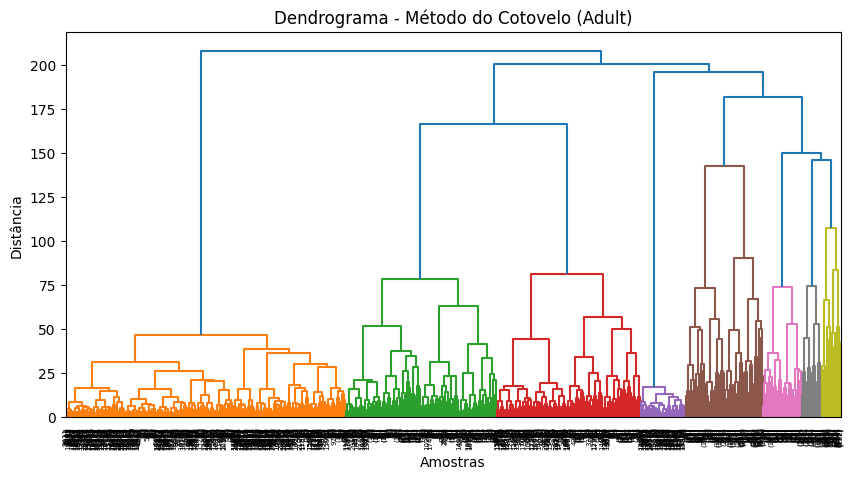

In [12]:
# Método do cotovelo para Agglomerative Clustering
# Usando linkage para visualizar o dendrograma

# Garante que a pasta 'img' existe
import os
os.makedirs('img', exist_ok=True)

plt.figure(figsize=(10, 5))
linked = linkage(X_train, method='ward')
dendrogram(linked, truncate_mode='level', p=10)
plt.title('Dendrograma - Método do Cotovelo (Adult)')
plt.xlabel('Amostras')
plt.ylabel('Distância')
plt.savefig('img/agglo_adult_dendrogram.png')
plt.show()

# Sugestão: escolha visual do número de clusters (exemplo: 2)

## 5. Implementação do Classificador Agglomerative Supervisionado

O classificador associa cada cluster ao rótulo mais frequente no conjunto de treino.

In [13]:
class AggloSupervisionado:
    def __init__(self, n_clusters=2):
        self.n_clusters = n_clusters
        self.agglo = AgglomerativeClustering(n_clusters=n_clusters)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.agglo.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.agglo.fit_predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 6. Treinamento e Avaliação do Classificador

Treinamos o classificador no conjunto de treino e avaliamos no conjunto de teste, mostrando acurácia e matriz de confusão.

In [14]:
n_clusters = 2  # Ajuste conforme o dendrograma

# Garante que a pasta 'img' existe
import os
os.makedirs('img', exist_ok=True)

clf = AggloSupervisionado(n_clusters=n_clusters)
clf.fit(X_train, y_train)

acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Agglomerative (Adult)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig('img/agglo_adult_confusion_matrix.png')
plt.show()

C:\Users\leona\AppData\Local\Temp\ipykernel_37000\1830346216.py:13: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  label = np.bincount(y[mask]).argmax()


ValueError: invalid literal for int() with base 10: '<=50K'

## 7. Repetição dos Experimentos

Repita o experimento 30 vezes, variando a semente, e salve as acurácias para análise estatística.

In [ ]:
acuracias = []
# Garante que a pasta 'img' existe
import os
os.makedirs('img', exist_ok=True)
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    acc, _ = clf.evaluate(X_test, y_test)
    acuracias.append(acc)

acuracias = np.array(acuracias)
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão: {acuracias.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - Agglomerative (Adult)')
plt.savefig('img/agglo_adult_accuracy_repetitions.png')
plt.show()

# Salvar acurácias para análise posterior
np.save('img/agglo_adult_accuracies.npy', acuracias)
np.savetxt('img/agglo_adult_accuracies.csv', acuracias, delimiter=',')

In [ ]:
from sklearn.metrics import mean_squared_error

# ...existing code para acuracias...

mse_list = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)

mse_array = np.array(mse_list)
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - Agglomerative (Adult)')
plt.savefig('img/agglo_adult_mse_repetitions.png')
plt.show()

# Salvar MSE para análise posterior
np.save('img/agglo_adult_mse_repetitions.npy', mse_array)
np.savetxt('img/agglo_adult_mse_repetitions.csv', mse_array, delimiter=',')

## 8. Análise dos Resultados

Comente os resultados obtidos, destacando a acurácia média, o desvio padrão e possíveis dificuldades do classificador Agglomerative no dataset Adult.